# Dataset 2 — Cityscapes Metric Calculation

This notebook evaluates the **same Qwen3-VL base model** and the **BDD100K fine-tuned Qwen3-VL + LoRA model** on the external Cityscapes evaluation set.

The notebook operates only on the two already-generated prediction dataframes:

- `cityscapes_base_dataframe.jsonl`
- `cityscapes_finetuned_dataframe.jsonl`

It does **not** regenerate predictions or modify the model.

**Imports and Paths**

In [ ]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    jaccard_score,
)
from nltk.translate.bleu_score import (
    corpus_bleu,
    sentence_bleu,
    SmoothingFunction,
)
from nltk.translate.meteor_score import meteor_score

DATA_DIR = Path(
    r"C:\Users\becker\Documents\Thesis\dataset\CityScapes"
)

BASE_PATH = DATA_DIR / "cityscapes_base_dataframe.jsonl"
FINETUNED_PATH = DATA_DIR / "cityscapes_finetuned_dataframe.jsonl"

RESULTS_DIR = DATA_DIR / "metric_results_ds2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_IMAGES = 267
EXPECTED_TASKS = 4
EXPECTED_ROWS = EXPECTED_IMAGES * EXPECTED_TASKS

OBJECT_LABELS = [
    "car",
    "truck",
    "bus",
    "person",
    "rider",
    "bicycle",
    "motorcycle",
    "train",
    "traffic light",
    "traffic sign",
]

SCENE_LABELS = [
    "city street",
    "highway",
    "residential",
    "parking lot",
    "tunnel",
    "gas station",
]

print("Metric configuration ready.")
print(f"Base dataframe: {BASE_PATH}")
print(f"Fine-tuned dataframe: {FINETUNED_PATH}")
print(f"Results directory: {RESULTS_DIR}")


Metric configuration ready.
Base dataframe: C:\Users\becker\Documents\Thesis\dataset\CityScapes\cityscapes_base_dataframe.jsonl
Fine-tuned dataframe: C:\Users\becker\Documents\Thesis\dataset\CityScapes\cityscapes_finetuned_dataframe.jsonl
Results directory: C:\Users\becker\Documents\Thesis\dataset\CityScapes\metric_results_ds2


**Load and Validate the Two Dataframes**

In [2]:
assert BASE_PATH.exists(), f"Base dataframe not found: {BASE_PATH}"
assert FINETUNED_PATH.exists(), f"Fine-tuned dataframe not found: {FINETUNED_PATH}"

df_base = pd.read_json(
    BASE_PATH,
    orient="records",
    lines=True,
)

df_fine = pd.read_json(
    FINETUNED_PATH,
    orient="records",
    lines=True,
)

required_columns = {
    "evaluation_id",
    "image_id",
    "task",
    "task_slug",
    "ground_truth",
    "predicted_output",
    "eval_status",
    "generation_error",
    "ground_truth_classes",
    "ground_truth_scene",
    "ground_truth_anomaly",
    "reference_caption",
    "output_token_count",
    "max_new_tokens",
}

for name, df in [
    ("Base", df_base),
    ("Fine-tuned", df_fine),
]:
    missing = required_columns - set(df.columns)
    assert not missing, f"{name} dataframe missing columns: {sorted(missing)}"

    assert len(df) == EXPECTED_ROWS, (
        f"{name} dataframe has {len(df)} rows; "
        f"expected {EXPECTED_ROWS}."
    )

    assert df["evaluation_id"].is_unique, (
        f"{name} dataframe contains duplicate evaluation IDs."
    )

    assert (df["eval_status"] == "Completed").all(), (
        f"{name} dataframe contains unfinished inference rows."
    )

    assert df["generation_error"].isna().all(), (
        f"{name} dataframe contains generation errors."
    )

    assert df["predicted_output"].astype(str).str.strip().ne("").all(), (
        f"{name} dataframe contains empty predictions."
    )

# Base/fine rows must represent exactly the same evaluation examples.
alignment_columns = [
    "evaluation_id",
    "image_id",
    "task_slug",
    "ground_truth",
]

for column in alignment_columns:
    base_values = df_base[column].fillna("").tolist()
    fine_values = df_fine[column].fillna("").tolist()

    assert base_values == fine_values, (
        f"Base/fine alignment mismatch in column: {column}"
    )

task_counts_base = df_base["task_slug"].value_counts()
task_counts_fine = df_fine["task_slug"].value_counts()

assert task_counts_base.equals(task_counts_fine)
assert (task_counts_base == EXPECTED_IMAGES).all()

print("Dataframes validated successfully.")
print(f"Rows per dataframe: {len(df_base)}")
print(f"Unique images: {df_base['image_id'].nunique()}")
print("\nRows per task:")
print(task_counts_base)


Dataframes validated successfully.
Rows per dataframe: 1068
Unique images: 267

Rows per task:
task_slug
multilabel_object_recognition        267
environmental_scene_understanding    267
hazard_and_anomaly_detection         267
traffic_scene_captioning             267
Name: count, dtype: int64


**Task-Specific Prediction Parsers**

In [3]:
OBJECT_PATTERNS = {
    "car": [r"\bcars?\b"],
    "truck": [r"\btrucks?\b"],
    "bus": [r"\bbus(?:es)?\b"],
    "person": [
        r"\bperson(?:s)?\b",
        r"\bpeople\b",
        r"\bpedestrians?\b",
    ],
    "rider": [
        r"\briders?\b",
        r"\bcyclists?\b",
    ],
    "bicycle": [
        r"\bbicycles?\b",
        r"\bbikes?\b",
    ],
    "motorcycle": [
        r"\bmotorcycles?\b",
        r"\bmotorbikes?\b",
    ],
    "train": [r"\btrains?\b"],
    "traffic light": [
        r"\btraffic\s+lights?\b",
    ],
    "traffic sign": [
        r"\btraffic\s+signs?\b",
    ],
}


def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[*_`#]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def has_nonnegated_match(text, pattern):
    for match in re.finditer(pattern, text):

        left_context = text[
            max(0, match.start() - 45):
            match.start()
        ]

        negated = re.search(
            r"\b(no|not|without|none|zero)\b"
            r"(?:\W+\w+){0,3}\W*$",
            left_context,
        )

        if not negated:
            return True

    return False


def parse_object_classes(text):
    text = normalize_text(text)

    detected = set()

    for label, patterns in OBJECT_PATTERNS.items():
        for pattern in patterns:
            if has_nonnegated_match(text, pattern):
                detected.add(label)
                break

    return detected


def parse_scene(text):
    text = normalize_text(text)

    explicit = re.search(
        r"\bscene\s*:\s*([^;\n,.]+)",
        text,
    )

    if explicit:
        candidate = explicit.group(1).strip()

        for label in SCENE_LABELS:
            if re.search(
                rf"\b{re.escape(label)}\b",
                candidate,
            ):
                return label

    for label in SCENE_LABELS:
        if re.search(
            rf"\b{re.escape(label)}\b",
            text,
        ):
            return label

    return None


def parse_hazard(text):
    text = normalize_text(text)
    decision = re.search(
        r"\bdecision\s*:\s*(yes|no)\b",
        text,
    )

    if decision:
        return 1 if decision.group(1) == "yes" else 0

    negative_patterns = [
        r"\bhazard\s*:\s*(?:no|none|absent|false)\b",
        r"\bhazard\s+type\s*:\s*none\b",
        r"\bpotential\s+hazards?\s*:\s*none\b",

        r"\bno\s+rule[- ]defined\s+visible\s+potential\s+hazards?\b",
        r"\bno\s+significant\s+hazards?\b",
        r"\bno\s+(?:visible\s+)?potential\s+hazards?\b",

        r"\bno\s+(?:such\s+)?hazards?\s+(?:is|are)\s+visible\b",

        r"\bno\s+such\s+hazards?\b",
        r"\bno\s+hazards?\b",
        r"\bnot\s+hazardous\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    positive_patterns = [
        r"\bhazard\s*:\s*(?:yes|present|true)\b",

        r"\bpotential\s+hazards?\s*:\s*(?!none\b)",

        r"\bhazard\s+type\s*:\s*(?!none\b)",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return None


def tokenize_caption(text):
    text = normalize_text(text)

    return re.findall(
        r"\b[\w'-]+\b",
        text,
    )


print("Prediction parsers defined.")

Prediction parsers defined.


**Parse Predictions and Validate Parser Coverage**

In [ ]:
parsed_base = df_base.copy()
parsed_fine = df_fine.copy()


def apply_parsers(df):

    df["parsed_prediction"] = pd.Series(
        [None] * len(df),
        dtype="object",
    )

    object_mask = (
        df["task_slug"]
        == "multilabel_object_recognition"
    )

    for idx in df.index[object_mask]:
        parsed_classes = parse_object_classes(
            df.at[idx, "predicted_output"]
        )

        df.at[idx, "parsed_prediction"] = sorted(
            parsed_classes
        )

    environment_mask = (
        df["task_slug"]
        == "environmental_scene_understanding"
    )

    for idx in df.index[environment_mask]:
        df.at[idx, "parsed_prediction"] = parse_scene(
            df.at[idx, "predicted_output"]
        )


    hazard_mask = (
        df["task_slug"]
        == "hazard_and_anomaly_detection"
    )

    for idx in df.index[hazard_mask]:
        df.at[idx, "parsed_prediction"] = parse_hazard(
            df.at[idx, "predicted_output"]
        )

    caption_mask = (
        df["task_slug"]
        == "traffic_scene_captioning"
    )

    for idx in df.index[caption_mask]:
        df.at[idx, "parsed_prediction"] = str(
            df.at[idx, "predicted_output"]
        ).strip()

    return df


parsed_base = apply_parsers(
    parsed_base
)

parsed_fine = apply_parsers(
    parsed_fine
)


audit_rows = []

for model_name, df in [
    ("Base Model", parsed_base),
    ("Fine-Tuned Model", parsed_fine),
]:

    scene_rows = df[
        df["task_slug"]
        == "environmental_scene_understanding"
    ]

    hazard_rows = df[
        df["task_slug"]
        == "hazard_and_anomaly_detection"
    ]

    object_rows = df[
        df["task_slug"]
        == "multilabel_object_recognition"
    ]

    unparsed_scene = int(
        scene_rows[
            "parsed_prediction"
        ].isna().sum()
    )

    unparsed_hazard = int(
        hazard_rows[
            "parsed_prediction"
        ].isna().sum()
    )

    empty_object_predictions = int(
        object_rows[
            "parsed_prediction"
        ]
        .apply(len)
        .eq(0)
        .sum()
    )

    explicit_scene_format = (
        scene_rows[
            "predicted_output"
        ]
        .astype(str)
        .str.contains(
            r"\bscene\s*:",
            case=False,
            regex=True,
        )
        .mean()
    )

    explicit_hazard_decision = (
        hazard_rows[
            "predicted_output"
        ]
        .astype(str)
        .str.contains(
            r"\bdecision\s*:\s*(?:yes|no)\b",
            case=False,
            regex=True,
        )
        .mean()
    )

    audit_rows.append({
        "Model": model_name,
        "Unparsed Scene Outputs": unparsed_scene,
        "Unparsed Hazard Outputs": unparsed_hazard,
        "Empty Object Parses": empty_object_predictions,
        "Explicit Scene Format Rate": explicit_scene_format,
        "Explicit Hazard Decision Rate": explicit_hazard_decision,
    })


parser_audit_summary = pd.DataFrame(
    audit_rows
)

print("Parser coverage summary:")

display(
    parser_audit_summary.style.format({
        "Explicit Scene Format Rate": "{:.2%}",
        "Explicit Hazard Decision Rate": "{:.2%}",
    })
)

for model_name, df in [
    ("Base Model", parsed_base),
    ("Fine-Tuned Model", parsed_fine),
]:

    unparsed_scene_rows = df[
        (
            df["task_slug"]
            == "environmental_scene_understanding"
        )
        &
        (
            df["parsed_prediction"].isna()
        )
    ]

    unparsed_hazard_rows = df[
        (
            df["task_slug"]
            == "hazard_and_anomaly_detection"
        )
        &
        (
            df["parsed_prediction"].isna()
        )
    ]

    if len(unparsed_scene_rows) > 0:

        print(
            f"\n{model_name} — "
            f"Unparsed scene outputs:"
        )

        display(
            unparsed_scene_rows[
                [
                    "evaluation_id",
                    "ground_truth_scene",
                    "predicted_output",
                ]
            ]
        )

    if len(unparsed_hazard_rows) > 0:

        print(
            f"\n{model_name} — "
            f"Unparsed hazard outputs:"
        )

        display(
            unparsed_hazard_rows[
                [
                    "evaluation_id",
                    "ground_truth_anomaly",
                    "predicted_output",
                ]
            ]
        )

assert (
    parser_audit_summary[
        "Unparsed Scene Outputs"
    ] == 0
).all(), (
    "At least one environmental output could not be parsed. "
    "Inspect the displayed rows before continuing."
)

assert (
    parser_audit_summary[
        "Unparsed Hazard Outputs"
    ] == 0
).all(), (
    "At least one hazard output could not be parsed. "
    "Inspect the displayed rows before continuing."
)

audit_examples = []

for model_name, df in [
    ("Base Model", parsed_base),
    ("Fine-Tuned Model", parsed_fine),
]:

    for task_slug in [
        "multilabel_object_recognition",
        "environmental_scene_understanding",
        "hazard_and_anomaly_detection",
        "traffic_scene_captioning",
    ]:

        subset = df[
            df["task_slug"]
            == task_slug
        ]

        sample = subset.sample(
            n=min(3, len(subset)),
            random_state=42,
        )

        for _, row in sample.iterrows():

            audit_examples.append({
                "Model": model_name,
                "Task": task_slug,
                "Evaluation ID": row[
                    "evaluation_id"
                ],
                "Ground Truth": row[
                    "ground_truth"
                ],
                "Raw Output": row[
                    "predicted_output"
                ],
                "Parsed Prediction": row[
                    "parsed_prediction"
                ],
            })


parser_audit_examples = pd.DataFrame(
    audit_examples
)

print(
    "\nRaw model output → parsed prediction audit:"
)

display(
    parser_audit_examples
)


print(
    "\nParser validation passed successfully."
)

Parser coverage summary:


,Model,Unparsed Scene Outputs,Unparsed Hazard Outputs,Empty Object Parses,Explicit Scene Format Rate,Explicit Hazard Decision Rate
0,Base Model,0,0,0,100.00%,76.03%
1,Fine-Tuned Model,0,0,0,100.00%,0.00%



Raw model output → parsed prediction audit:


,Model,Task,Evaluation ID,Ground Truth,Raw Output,Parsed Prediction
0,Base Model,multilabel_object_recognition,multilabel_object_recognition::frankfurt_00000...,"car, person, rider, bicycle, traffic sign","person, traffic sign, traffic light, motorcycl...","[bicycle, motorcycle, person, traffic light, t..."
1,Base Model,multilabel_object_recognition,multilabel_object_recognition::frankfurt_00000...,"car, person, rider, bicycle, motorcycle, traff...","car, bus, bicycle, traffic sign","[bicycle, bus, car, traffic sign]"
2,Base Model,multilabel_object_recognition,multilabel_object_recognition::frankfurt_00000...,"car, person, rider, bicycle, traffic sign","car, person, rider, bicycle, traffic sign","[bicycle, car, person, rider, traffic sign]"
3,Base Model,environmental_scene_understanding,environmental_scene_understanding::frankfurt_0...,scene: city street,weather: clear; scene: city street,city street
4,Base Model,environmental_scene_understanding,environmental_scene_understanding::frankfurt_0...,scene: city street,weather: clear; scene: city street,city street
5,Base Model,environmental_scene_understanding,environmental_scene_understanding::frankfurt_0...,scene: city street,weather: clear; scene: city street,city street
6,Base Model,hazard_and_anomaly_detection,hazard_and_anomaly_detection::frankfurt_000001...,No Cityscapes proxy hazard is present.,"No, the image does not contain a rule-defined ...",0
7,Base Model,hazard_and_anomaly_detection,hazard_and_anomaly_detection::frankfurt_000000...,No Cityscapes proxy hazard is present.,No hazard detected.\n\n- Decision: No\n- Hazar...,0
8,Base Model,hazard_and_anomaly_detection,hazard_and_anomaly_detection::frankfurt_000001...,No Cityscapes proxy hazard is present.,Decision: No\n\nHazard type: None\n\nInvolved ...,0
9,Base Model,traffic_scene_captioning,traffic_scene_captioning::frankfurt_000001_012738,"A daytime city street scene with visible cars,...",The scene depicts a daytime urban street with ...,The scene depicts a daytime urban street with ...



Parser validation passed successfully.


**Multilabel Object Recognition Metrics**

In [ ]:
def build_multilabel_arrays(df):

    task_df = df[
        df["task_slug"]
        == "multilabel_object_recognition"
    ].copy()

    y_true = np.array([
        [
            int(label in set(classes))
            for label in OBJECT_LABELS
        ]
        for classes in task_df[
            "ground_truth_classes"
        ]
    ])

    y_pred = np.array([
        [
            int(label in set(classes))
            for label in OBJECT_LABELS
        ]
        for classes in task_df[
            "parsed_prediction"
        ]
    ])

    return task_df, y_true, y_pred


def calculate_object_metrics(df):

    task_df, y_true, y_pred = (
        build_multilabel_arrays(df)
    )

    micro_precision = precision_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    micro_recall = recall_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    micro_f1 = f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    mean_jaccard = jaccard_score(
        y_true,
        y_pred,
        average="samples",
        zero_division=0,
    )

    exact_match = accuracy_score(
        y_true,
        y_pred,
    )

    tp = int(
        np.logical_and(
            y_true == 1,
            y_pred == 1,
        ).sum()
    )

    fp = int(
        np.logical_and(
            y_true == 0,
            y_pred == 1,
        ).sum()
    )

    fn = int(
        np.logical_and(
            y_true == 1,
            y_pred == 0,
        ).sum()
    )

    hallucination_rate = (
        fp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    return {
        "Micro Precision": micro_precision,
        "Micro Recall": micro_recall,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
        "Mean Jaccard": mean_jaccard,
        "Exact Match Accuracy": exact_match,
        "Object-Class Hallucination Rate": hallucination_rate,
        "TP": tp,
        "FP": fp,
        "FN": fn,
    }


object_base = calculate_object_metrics(
    parsed_base
)

object_fine = calculate_object_metrics(
    parsed_fine
)


OBJECT_METRIC_NAMES = [
    "Micro Precision",
    "Micro Recall",
    "Micro F1",
    "Macro F1",
    "Mean Jaccard",
    "Exact Match Accuracy",
    "Object-Class Hallucination Rate",
]


object_summary = pd.DataFrame({
    "Metric": OBJECT_METRIC_NAMES,

    "Base Model": [
        object_base[metric]
        for metric in OBJECT_METRIC_NAMES
    ],

    "Fine-Tuned Model": [
        object_fine[metric]
        for metric in OBJECT_METRIC_NAMES
    ],
})


object_summary["Delta"] = (
    object_summary["Fine-Tuned Model"]
    - object_summary["Base Model"]
)


display(
    object_summary.style.format({
        "Base Model": "{:.4f}",
        "Fine-Tuned Model": "{:.4f}",
        "Delta": "{:+.4f}",
    })
)


print("\nAggregate label decisions:")

display(
    pd.DataFrame({
        "Model": [
            "Base Model",
            "Fine-Tuned Model",
        ],
        "TP": [
            object_base["TP"],
            object_fine["TP"],
        ],
        "FP": [
            object_base["FP"],
            object_fine["FP"],
        ],
        "FN": [
            object_base["FN"],
            object_fine["FN"],
        ],
    })
)

,Metric,Base Model,Fine-Tuned Model,Delta
0,Micro Precision,0.8459,0.6111,-0.2348
1,Micro Recall,0.7756,0.8456,+0.0699
2,Micro F1,0.8092,0.7095,-0.0998
3,Macro F1,0.6569,0.6195,-0.0374
4,Mean Jaccard,0.6965,0.5285,-0.1680
5,Exact Match Accuracy,0.1423,0.0037,-0.1386
6,Object-Class Hallucination Rate,0.1541,0.3889,+0.2348



Aggregate label decisions:


,Model,TP,FP,FN
0,Base Model,1120,204,324
1,Fine-Tuned Model,1221,777,223


**Object-Class Hallucination Rate**

Multilabel Object Recognition Hallucination Analysis:


,Model,Total Predicted Object Classes,Hallucinated Object Classes,Images with Hallucination,Object-Class Hallucination Rate (%),Hallucination Incidence (%),Mean Hallucinated Classes per Image
0,Base Model,1324,204,121,15.408,45.318,0.764
1,Fine-Tuned Model,1998,777,219,38.889,82.022,2.910


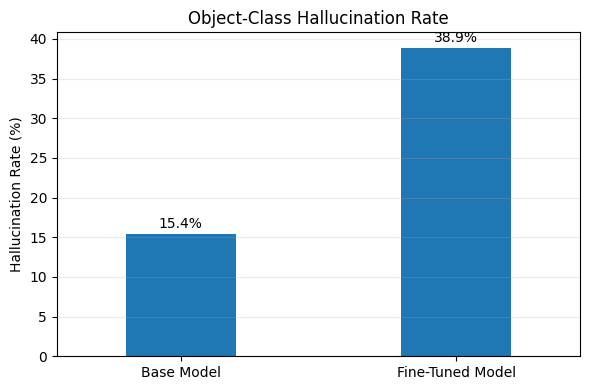

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



def calculate_hallucination_metrics(
    dataframe,
    model_name,
):
    

    task_df = dataframe[
        dataframe["task_slug"]
        == "multilabel_object_recognition"
    ].copy()


    total_predicted_classes = 0
    total_hallucinated_classes = 0

    images_with_hallucination = 0

    image_details = []


    for _, row in task_df.iterrows():

        # Ground-truth classes
        ground_truth_classes = set(
            row["ground_truth_classes"]
        )


        # Parsed model prediction
        predicted_classes = set(
            row["parsed_prediction"]
        )


        # Predicted classes absent from ground truth
        hallucinated_classes = (
            predicted_classes
            - ground_truth_classes
        )


        predicted_count = len(
            predicted_classes
        )

        hallucinated_count = len(
            hallucinated_classes
        )


        total_predicted_classes += (
            predicted_count
        )

        total_hallucinated_classes += (
            hallucinated_count
        )


        if hallucinated_count > 0:

            images_with_hallucination += 1


        image_details.append(
            {
                "evaluation_id":
                    row["evaluation_id"],

                "Model":
                    model_name,

                "Ground Truth Classes":
                    sorted(
                        ground_truth_classes
                    ),

                "Predicted Classes":
                    sorted(
                        predicted_classes
                    ),

                "Hallucinated Classes":
                    sorted(
                        hallucinated_classes
                    ),

                "Predicted Class Count":
                    predicted_count,

                "Hallucinated Class Count":
                    hallucinated_count,

                "Has Hallucination":
                    int(
                        hallucinated_count > 0
                    ),
            }
        )


    hallucination_rate = (
        total_hallucinated_classes
        / total_predicted_classes
        if total_predicted_classes > 0
        else 0.0
    )


    hallucination_incidence = (
        images_with_hallucination
        / len(task_df)
        if len(task_df) > 0
        else 0.0
    )


    mean_hallucinated_classes = (
        total_hallucinated_classes
        / len(task_df)
        if len(task_df) > 0
        else 0.0
    )


    summary = {

        "Model":
            model_name,

        "Total Images":
            len(task_df),

        "Total Predicted Object Classes":
            total_predicted_classes,

        "Hallucinated Object Classes":
            total_hallucinated_classes,

        "Images with Hallucination":
            images_with_hallucination,

        "Object-Class Hallucination Rate":
            hallucination_rate,

        "Hallucination Incidence":
            hallucination_incidence,

        "Mean Hallucinated Classes per Image":
            mean_hallucinated_classes,
    }


    details = pd.DataFrame(
        image_details
    )


    return summary, details

(
    base_hallucination_summary,
    base_hallucination_details,
) = calculate_hallucination_metrics(
    parsed_base,
    "Base Model",
)


(
    fine_hallucination_summary,
    fine_hallucination_details,
) = calculate_hallucination_metrics(
    parsed_fine,
    "Fine-Tuned Model",
)

hallucination_details = pd.concat(
    [
        base_hallucination_details,
        fine_hallucination_details,
    ],
    ignore_index=True,
)

mor_hallucination_results = pd.DataFrame(
    [
        base_hallucination_summary,
        fine_hallucination_summary,
    ]
)


# Percentage columns for reporting
mor_hallucination_results[
    "Object-Class Hallucination Rate (%)"
] = (
    mor_hallucination_results[
        "Object-Class Hallucination Rate"
    ]
    * 100
)


mor_hallucination_results[
    "Hallucination Incidence (%)"
] = (
    mor_hallucination_results[
        "Hallucination Incidence"
    ]
    * 100
)

print(
    "Multilabel Object Recognition "
    "Hallucination Analysis:"
)


display(
    mor_hallucination_results[
        [
            "Model",
            "Total Predicted Object Classes",
            "Hallucinated Object Classes",
            "Images with Hallucination",
            "Object-Class Hallucination Rate (%)",
            "Hallucination Incidence (%)",
            "Mean Hallucinated Classes per Image",
        ]
    ].round(3)
)

ax = mor_hallucination_results.plot(
    x="Model",
    y="Object-Class Hallucination Rate (%)",
    kind="bar",
    legend=False,
    figsize=(6, 4),
    width=0.4,
)


ax.set_title(
    "Object-Class Hallucination Rate"
)

ax.set_xlabel("")

ax.set_ylabel(
    "Hallucination Rate (%)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
    )

plt.tight_layout()
plt.show()

**Per-Class Object Metrics**

In [ ]:

_, y_true_base, y_pred_base = build_multilabel_arrays(
    parsed_base
)
_, y_true_fine, y_pred_fine = build_multilabel_arrays(
    parsed_fine
)

per_class_rows = []

for index, label in enumerate(OBJECT_LABELS):
    for model_name, y_true, y_pred in [
        ("Base Model", y_true_base, y_pred_base),
        ("Fine-Tuned Model", y_true_fine, y_pred_fine),
    ]:
        per_class_rows.append({
            "Class": label,
            "Model": model_name,
            "Support": int(y_true[:, index].sum()),
            "Precision": precision_score(
                y_true[:, index],
                y_pred[:, index],
                zero_division=0,
            ),
            "Recall": recall_score(
                y_true[:, index],
                y_pred[:, index],
                zero_division=0,
            ),
            "F1": f1_score(
                y_true[:, index],
                y_pred[:, index],
                zero_division=0,
            ),
            "Predicted Positives": int(
                y_pred[:, index].sum()
            ),
        })

object_per_class = pd.DataFrame(per_class_rows)

display(
    object_per_class.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
    })
)


,Class,Model,Support,Precision,Recall,F1,Predicted Positives
0,car,Base Model,260,1.0000,0.9231,0.9600,240
1,car,Fine-Tuned Model,260,0.9809,0.9885,0.9847,262
2,truck,Base Model,34,0.2410,0.5882,0.3419,83
3,truck,Fine-Tuned Model,34,0.1553,1.0000,0.2688,219
4,bus,Base Model,43,0.4444,0.8372,0.5806,81
5,bus,Fine-Tuned Model,43,0.1881,0.9535,0.3142,218
6,person,Base Model,245,0.9427,0.8735,0.9068,227
7,person,Fine-Tuned Model,245,0.9488,0.8327,0.8870,215
8,rider,Base Model,130,0.8068,0.5462,0.6514,88
9,rider,Fine-Tuned Model,130,0.5412,0.8077,0.6481,194


**Environmental Scene Accuracy**

In [ ]:
def calculate_scene_metrics(df):
    task_df = df[
        df["task_slug"]
        == "environmental_scene_understanding"
    ].copy()

    assert task_df["ground_truth_scene"].notna().all()
    assert task_df["parsed_prediction"].notna().all()

    scene_accuracy = accuracy_score(
        task_df["ground_truth_scene"],
        task_df["parsed_prediction"],
    )

    return task_df, {
        "Scene Accuracy": scene_accuracy,
        "Correct": int(
            (
                task_df["ground_truth_scene"]
                == task_df["parsed_prediction"]
            ).sum()
        ),
        "Total": len(task_df),
    }


scene_base_df, scene_base = calculate_scene_metrics(
    parsed_base
)
scene_fine_df, scene_fine = calculate_scene_metrics(
    parsed_fine
)

scene_summary = pd.DataFrame({
    "Metric": ["Scene Accuracy"],
    "Base Model": [scene_base["Scene Accuracy"]],
    "Fine-Tuned Model": [scene_fine["Scene Accuracy"]],
})

scene_summary["Delta"] = (
    scene_summary["Fine-Tuned Model"]
    - scene_summary["Base Model"]
)

display(
    scene_summary.style.format({
        "Base Model": "{:.4f}",
        "Fine-Tuned Model": "{:.4f}",
        "Delta": "{:+.4f}",
    })
)

print("\nScene prediction distribution — Base Model:")
print(
    scene_base_df["parsed_prediction"].value_counts(
        dropna=False
    )
)

print("\nScene prediction distribution — Fine-Tuned Model:")
print(
    scene_fine_df["parsed_prediction"].value_counts(
        dropna=False
    )
)

,Metric,Base Model,Fine-Tuned Model,Delta
0,Scene Accuracy,1.0000,0.9963,-0.0037



Scene prediction distribution — Base Model:
parsed_prediction
city street    267
Name: count, dtype: int64

Scene prediction distribution — Fine-Tuned Model:
parsed_prediction
city street    266
highway          1
Name: count, dtype: int64


**Hazard Classification Metrics**

In [ ]:
def calculate_hazard_metrics(df):

    task_df = df[
        df["task_slug"]
        == "hazard_and_anomaly_detection"
    ].copy()

    y_true = (
        task_df["ground_truth_anomaly"]
        .astype(int)
        .to_numpy()
    )

    y_pred = (
        task_df["parsed_prediction"]
        .astype(int)
        .to_numpy()
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred,
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0,
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0,
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred,
    )

    false_alarm_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    predicted_hazard_rate = float(
        y_pred.mean()
    )

    return {
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc,
        "False Alarm Rate": false_alarm_rate,
        "Predicted Hazard Rate": predicted_hazard_rate,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


hazard_base = calculate_hazard_metrics(
    parsed_base
)

hazard_fine = calculate_hazard_metrics(
    parsed_fine
)


HAZARD_METRIC_NAMES = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "False Alarm Rate",
    "Predicted Hazard Rate",
]


hazard_summary = pd.DataFrame({
    "Metric": HAZARD_METRIC_NAMES,

    "Base Model": [
        hazard_base[metric]
        for metric in HAZARD_METRIC_NAMES
    ],

    "Fine-Tuned Model": [
        hazard_fine[metric]
        for metric in HAZARD_METRIC_NAMES
    ],
})


hazard_summary["Delta"] = (
    hazard_summary["Fine-Tuned Model"]
    - hazard_summary["Base Model"]
)


hazard_confusion = pd.DataFrame({
    "Model": [
        "Base Model",
        "Fine-Tuned Model",
    ],

    "True Negatives": [
        hazard_base["TN"],
        hazard_fine["TN"],
    ],

    "False Positives": [
        hazard_base["FP"],
        hazard_fine["FP"],
    ],

    "False Negatives": [
        hazard_base["FN"],
        hazard_fine["FN"],
    ],

    "True Positives": [
        hazard_base["TP"],
        hazard_fine["TP"],
    ],
})


display(
    hazard_summary.style.format({
        "Base Model": "{:.4f}",
        "Fine-Tuned Model": "{:.4f}",
        "Delta": "{:+.4f}",
    })
)

print("\nConfusion matrix counts:")
display(hazard_confusion)

,Metric,Base Model,Fine-Tuned Model,Delta
0,Accuracy,0.8914,0.1348,-0.7566
1,Balanced Accuracy,0.4818,0.5324,+0.0506
2,Precision,0.0000,0.0797,+0.0797
3,Recall,0.0000,1.0000,+1.0000
4,F1,0.0000,0.1476,+0.1476
5,MCC,-0.0531,0.0718,+0.1250
6,False Alarm Rate,0.0364,0.9352,+0.8988
7,Predicted Hazard Rate,0.0337,0.9401,+0.9064



Confusion matrix counts:


,Model,True Negatives,False Positives,False Negatives,True Positives
0,Base Model,238,9,20,0
1,Fine-Tuned Model,16,231,0,20


**False Alarm Rate**

In [18]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def calculate_false_alarm_rate(
    dataframe,
    model_name,
):

    task_df = dataframe[
        dataframe["task_slug"]
        == "hazard_and_anomaly_detection"
    ].copy()


    y_true = (
        task_df[
            "ground_truth_anomaly"
        ]
        .astype(int)
        .to_numpy()
    )


    y_pred = (
        task_df[
            "parsed_prediction"
        ]
        .astype(int)
        .to_numpy()
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()


    actual_non_hazards = (
        tn + fp
    )


    false_alarm_rate = (
        fp
        / actual_non_hazards
        if actual_non_hazards > 0
        else 0.0
    )


    specificity = (
        tn
        / actual_non_hazards
        if actual_non_hazards > 0
        else 0.0
    )


    return {

        "Model":
            model_name,

        "Actual Non-Hazard Scenes":
            int(
                actual_non_hazards
            ),

        "True Negatives":
            int(tn),

        "False Positives":
            int(fp),

        "False Alarm Rate":
            float(
                false_alarm_rate
            ),

        "False Alarm Rate (%)":
            float(
                false_alarm_rate
                * 100
            ),

        "Specificity":
            float(
                specificity
            ),

        "Specificity (%)":
            float(
                specificity
                * 100
            ),
    }

base_false_alarm = (
    calculate_false_alarm_rate(
        parsed_base,
        "Base Model",
    )
)

fine_false_alarm = (
    calculate_false_alarm_rate(
        parsed_fine,
        "Fine-Tuned Model",
    )
)

hazard_false_alarm_results = pd.DataFrame(
    [
        base_false_alarm,
        fine_false_alarm,
    ]
)



print(
    "Hazard and Anomaly Detection "
    "False Alarm Rate Analysis:"
)


display(
    hazard_false_alarm_results[
        [
            "Model",
            "Actual Non-Hazard Scenes",
            "True Negatives",
            "False Positives",
            "False Alarm Rate (%)",
            "Specificity (%)",
        ]
    ].round(3)
)

Hazard and Anomaly Detection False Alarm Rate Analysis:


,Model,Actual Non-Hazard Scenes,True Negatives,False Positives,False Alarm Rate (%),Specificity (%)
0,Base Model,247,238,9,3.644,96.356
1,Fine-Tuned Model,247,16,231,93.522,6.478


**Hazard Confusion Matrix Visualization**

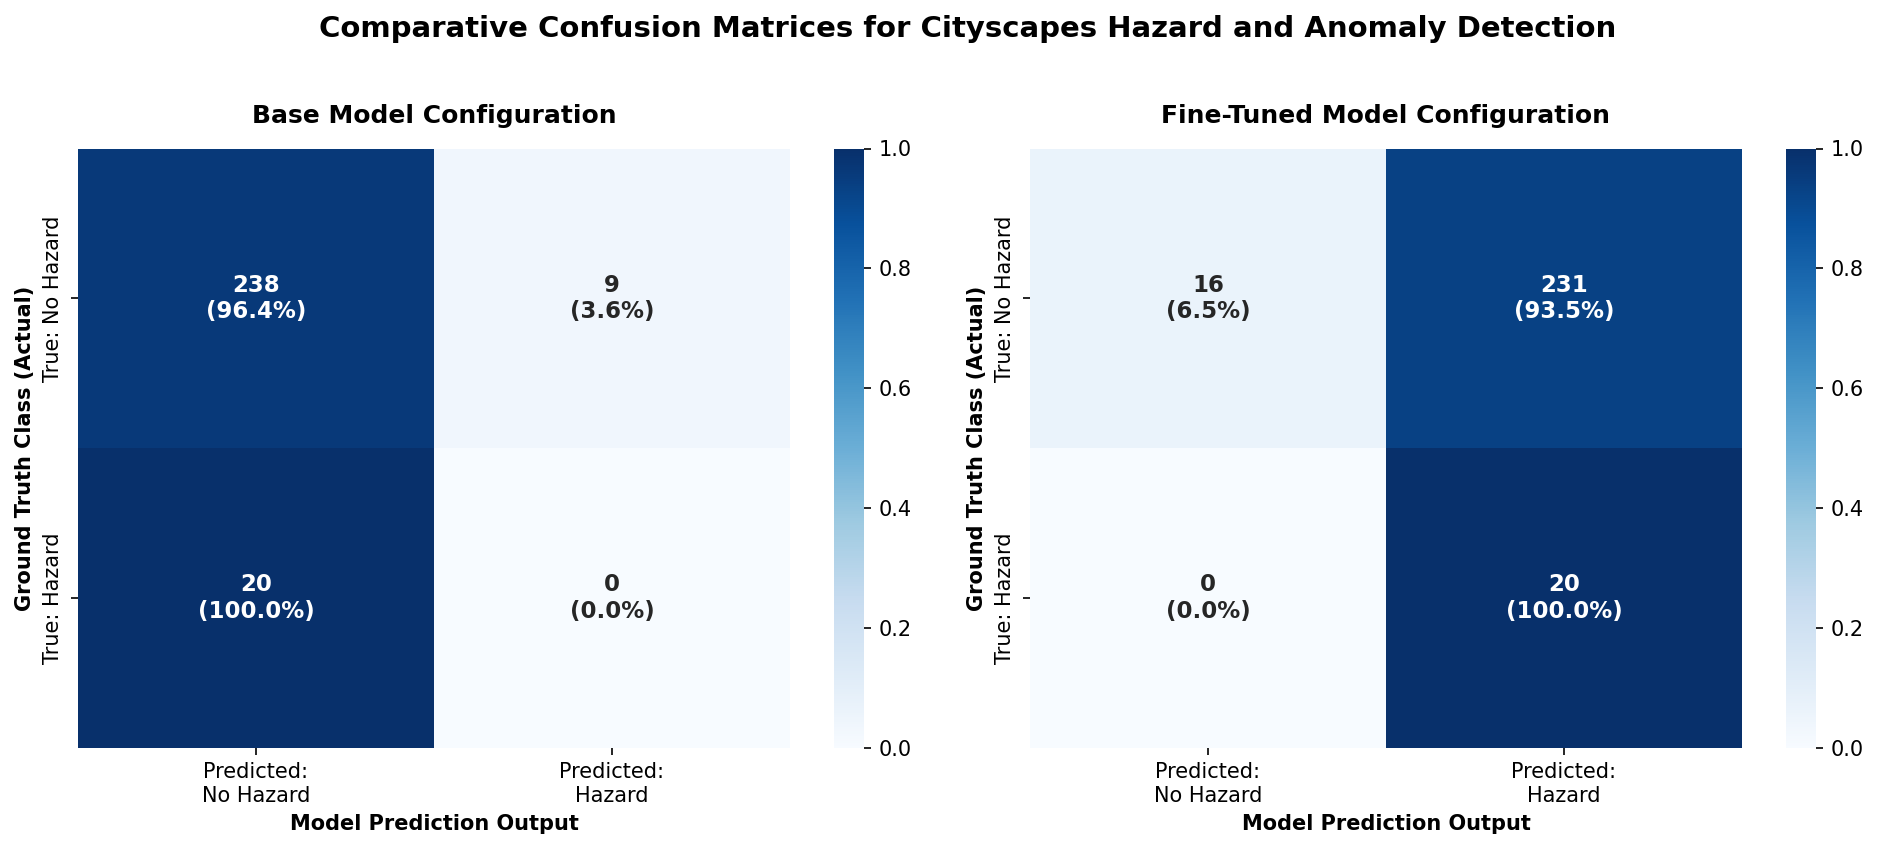

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Base Model,238,9,20,0
1,Fine-Tuned Model,16,231,0,20


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

base_confusion_data = parsed_base[
    parsed_base["task_slug"]
    == "hazard_and_anomaly_detection"
].copy()

finetuned_confusion_data = parsed_fine[
    parsed_fine["task_slug"]
    == "hazard_and_anomaly_detection"
].copy()


# Verify base/fine alignment before visualization.
assert (
    base_confusion_data["evaluation_id"].tolist()
    ==
    finetuned_confusion_data["evaluation_id"].tolist()
), "Base and fine-tuned hazard rows are not aligned."


assert (
    base_confusion_data[
        "ground_truth_anomaly"
    ].astype(int).tolist()
    ==
    finetuned_confusion_data[
        "ground_truth_anomaly"
    ].astype(int).tolist()
), "Base and fine-tuned ground truths differ."


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    dpi=150,
)


models_to_plot = [
    (
        "Base Model",
        base_confusion_data,
        axes[0],
    ),
    (
        "Fine-Tuned Model",
        finetuned_confusion_data,
        axes[1],
    ),
]


confusion_matrix_records = []

for title, model_data, ax in models_to_plot:

    y_true = (
        model_data[
            "ground_truth_anomaly"
        ]
        .astype(int)
        .to_numpy()
    )

    y_pred = (
        model_data[
            "parsed_prediction"
        ]
        .astype(int)
        .to_numpy()
    )

    target_labels = [0, 1]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=target_labels,
    )

    tn, fp, fn, tp = cm.ravel()


    confusion_matrix_records.append(
        {
            "Model": title,
            "True Negatives": int(tn),
            "False Positives": int(fp),
            "False Negatives": int(fn),
            "True Positives": int(tp),
        }
    )

    row_sums = (
        cm.sum(axis=1)[:, np.newaxis]
    )

    row_sums_safe = np.where(
        row_sums == 0,
        1,
        row_sums,
    )

    cm_normalized = (
        cm.astype(float)
        / row_sums_safe
    )

    group_counts = [
        f"{value:.0f}"
        for value in cm.flatten()
    ]

    group_percentages = []

    for row_index in range(2):

        row_total = (
            cm[row_index].sum()
        )

        for column_index in range(2):

            value = cm[
                row_index,
                column_index,
            ]

            percentage = (
                value / row_total * 100
                if row_total > 0
                else 0.0
            )

            group_percentages.append(
                f"{percentage:.1f}%"
            )


    annotation_labels = [
        f"{count}\n({percentage})"
        for count, percentage in zip(
            group_counts,
            group_percentages,
        )
    ]

    annotation_labels = np.asarray(
        annotation_labels
    ).reshape(2, 2)

    sns.heatmap(
        cm_normalized,
        annot=annotation_labels,
        fmt="",
        cmap="Blues",
        cbar=True,
        vmin=0,
        vmax=1,
        xticklabels=[
            "Predicted:\nNo Hazard",
            "Predicted:\nHazard",
        ],
        yticklabels=[
            "True: No Hazard",
            "True: Hazard",
        ],
        annot_kws={
            "size": 11,
            "weight": "bold",
        },
        ax=ax,
    )


    ax.set_title(
        f"{title} Configuration",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )

    ax.set_ylabel(
        "Ground Truth Class (Actual)",
        fontsize=10,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Model Prediction Output",
        fontsize=10,
        fontweight="bold",
    )


plt.suptitle(
    "Comparative Confusion Matrices for "
    "Cityscapes Hazard and Anomaly Detection",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

hazard_confusion_matrix_results = pd.DataFrame(
    confusion_matrix_records
)

display(
    hazard_confusion_matrix_results
)

**Caption Metrics and Generation Truncation**

In [ ]:
import nltk
import pandas as pd

from nltk.translate.bleu_score import (
    corpus_bleu,
    sentence_bleu,
    SmoothingFunction,
)

from nltk.translate.meteor_score import meteor_score

try:
    from nltk.corpus import wordnet
    _ = wordnet.synsets("car")

except LookupError:

    print(
        "NLTK WordNet resources not found. "
        "Attempting one-time download..."
    )

    nltk.download(
        "wordnet",
        quiet=True,
    )

    nltk.download(
        "omw-1.4",
        quiet=True,
    )

    from nltk.corpus import wordnet
    _ = wordnet.synsets("car")


def calculate_caption_metrics(
    dataframe,
    model_name,
):

    task_df = dataframe[
        dataframe["task_slug"]
        == "traffic_scene_captioning"
    ].copy()


    assert len(task_df) == EXPECTED_IMAGES, (
        f"{model_name}: Expected "
        f"{EXPECTED_IMAGES} caption rows, "
        f"found {len(task_df)}."
    )


    assert (
        task_df[
            "reference_caption"
        ]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ), (
        f"{model_name}: Empty reference captions detected."
    )


    assert (
        task_df[
            "predicted_output"
        ]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    ), (
        f"{model_name}: Empty predicted captions detected."
    )

    smoothing = (
        SmoothingFunction().method1
    )


    corpus_references = []
    corpus_hypotheses = []

    detail_rows = []


    # Aggregate object-class counts
    total_entity_tp = 0
    total_entity_fp = 0
    total_entity_fn = 0

    for _, row in task_df.iterrows():

        reference_caption = str(
            row["reference_caption"]
        ).strip()

        predicted_caption = str(
            row["predicted_output"]
        ).strip()

        reference_tokens = tokenize_caption(
            reference_caption
        )

        prediction_tokens = tokenize_caption(
            predicted_caption
        )


        corpus_references.append(
            [reference_tokens]
        )

        corpus_hypotheses.append(
            prediction_tokens
        )

        sentence_bleu_4 = sentence_bleu(
            [reference_tokens],
            prediction_tokens,
            weights=(
                0.25,
                0.25,
                0.25,
                0.25,
            ),
            smoothing_function=smoothing,
        )

        if (
            reference_tokens
            and prediction_tokens
        ):

            meteor = meteor_score(
                [reference_tokens],
                prediction_tokens,
            )

        else:
            meteor = 0.0

        reference_entities = (
            parse_object_classes(
                reference_caption
            )
        )

        predicted_entities = (
            parse_object_classes(
                predicted_caption
            )
        )

        entity_tp = len(
            reference_entities
            & predicted_entities
        )

        entity_fp = len(
            predicted_entities
            - reference_entities
        )

        entity_fn = len(
            reference_entities
            - predicted_entities
        )


        total_entity_tp += entity_tp
        total_entity_fp += entity_fp
        total_entity_fn += entity_fn


        entity_precision = (
            entity_tp
            /
            (
                entity_tp
                + entity_fp
            )
            if (
                entity_tp
                + entity_fp
            ) > 0
            else 0.0
        )


        entity_recall = (
            entity_tp
            /
            (
                entity_tp
                + entity_fn
            )
            if (
                entity_tp
                + entity_fn
            ) > 0
            else 0.0
        )


        entity_f1 = (
            2
            * entity_precision
            * entity_recall
            /
            (
                entity_precision
                + entity_recall
            )
            if (
                entity_precision
                + entity_recall
            ) > 0
            else 0.0
        )

        predicted_entity_count = len(
            predicted_entities
        )

        has_predicted_entity = int(
            predicted_entity_count > 0
        )

        detail_rows.append(
            {
                "evaluation_id":
                    row["evaluation_id"],

                "Model":
                    model_name,

                "Reference Caption":
                    reference_caption,

                "Predicted Caption":
                    predicted_caption,

                "BLEU-4":
                    sentence_bleu_4,

                "METEOR":
                    meteor,

                "Reference Entities":
                    sorted(
                        reference_entities
                    ),

                "Predicted Entities":
                    sorted(
                        predicted_entities
                    ),

                "Entity Precision":
                    entity_precision,

                "Entity Recall":
                    entity_recall,

                "Entity F1":
                    entity_f1,

                "Predicted Entity Count":
                    predicted_entity_count,

                "Has Predicted Entity":
                    has_predicted_entity,
            }
        )

    details = pd.DataFrame(
        detail_rows
    )
    
    corpus_bleu_4 = corpus_bleu(
        corpus_references,
        corpus_hypotheses,
        weights=(
            0.25,
            0.25,
            0.25,
            0.25,
        ),
        smoothing_function=smoothing,
    )

    caption_object_precision = (
        total_entity_tp
        /
        (
            total_entity_tp
            + total_entity_fp
        )
        if (
            total_entity_tp
            + total_entity_fp
        ) > 0
        else 0.0
    )


    caption_object_recall = (
        total_entity_tp
        /
        (
            total_entity_tp
            + total_entity_fn
        )
        if (
            total_entity_tp
            + total_entity_fn
        ) > 0
        else 0.0
    )


    caption_object_f1 = (
        2
        * caption_object_precision
        * caption_object_recall
        /
        (
            caption_object_precision
            + caption_object_recall
        )
        if (
            caption_object_precision
            + caption_object_recall
        ) > 0
        else 0.0
    )

    entity_mention_rate = float(
        details[
            "Has Predicted Entity"
        ].mean()
    )


    mean_predicted_object_classes = float(
        details[
            "Predicted Entity Count"
        ].mean()
    )

    summary = {

        "Model":
            model_name,

        "Corpus BLEU-4":
            float(
                corpus_bleu_4
            ),

        "Mean Sentence BLEU-4":
            float(
                details[
                    "BLEU-4"
                ].mean()
            ),

        "Mean METEOR":
            float(
                details[
                    "METEOR"
                ].mean()
            ),

        "Caption Object Precision":
            float(
                caption_object_precision
            ),

        "Caption Object Recall":
            float(
                caption_object_recall
            ),

        "Caption Object F1":
            float(
                caption_object_f1
            ),

        "Entity Mention Rate":
            entity_mention_rate,

        "Mean Predicted Object Classes":
            mean_predicted_object_classes,
    }


    return (
        summary,
        details,
    )

(
    base_caption_summary,
    base_caption_metric_details,
) = calculate_caption_metrics(
    parsed_base,
    "Base Model",
)

(
    fine_caption_summary,
    fine_caption_metric_details,
) = calculate_caption_metrics(
    parsed_fine,
    "Fine-Tuned Model",
)

caption_metric_details = pd.concat(
    [
        base_caption_metric_details,
        fine_caption_metric_details,
    ],
    ignore_index=True,
)

caption_metrics = pd.DataFrame(
    [
        base_caption_summary,
        fine_caption_summary,
    ]
)

metric_columns = [
    column
    for column
    in caption_metrics.columns
    if column != "Model"
]


caption_summary = pd.DataFrame(
    {
        "Metric":
            metric_columns,

        "Base Model":
            [
                base_caption_summary[
                    metric
                ]
                for metric
                in metric_columns
            ],

        "Fine-Tuned Model":
            [
                fine_caption_summary[
                    metric
                ]
                for metric
                in metric_columns
            ],
    }
)


caption_summary["Delta"] = (
    caption_summary[
        "Fine-Tuned Model"
    ]
    -
    caption_summary[
        "Base Model"
    ]
)


print(
    "Traffic Scene Captioning metrics:"
)


display(
    caption_summary.style.format(
        {
            "Base Model":
                "{:.4f}",

            "Fine-Tuned Model":
                "{:.4f}",

            "Delta":
                "{:+.4f}",
        }
    )
)

caption_content_diagnostics = pd.DataFrame(
    {
        "Model": [
            "Base Model",
            "Fine-Tuned Model",
        ],

        "Captions Mentioning Evaluated Objects": [
            int(
                base_caption_metric_details[
                    "Has Predicted Entity"
                ].sum()
            ),

            int(
                fine_caption_metric_details[
                    "Has Predicted Entity"
                ].sum()
            ),
        ],

        "Total Captions": [
            len(
                base_caption_metric_details
            ),

            len(
                fine_caption_metric_details
            ),
        ],

        "Total Predicted Object-Class Mentions": [
            int(
                base_caption_metric_details[
                    "Predicted Entity Count"
                ].sum()
            ),

            int(
                fine_caption_metric_details[
                    "Predicted Entity Count"
                ].sum()
            ),
        ],
    }
)


print(
    "\nCaption object-content diagnostics:"
)


display(
    caption_content_diagnostics
)

Traffic Scene Captioning metrics:


,Metric,Base Model,Fine-Tuned Model,Delta
0,Corpus BLEU-4,0.0014,0.0039,+0.0024
1,Mean Sentence BLEU-4,0.0079,0.0211,+0.0133
2,Mean METEOR,0.2526,0.2296,-0.0230
3,Caption Object Precision,0.9631,1.0000,+0.0369
4,Caption Object Recall,0.2348,0.0007,-0.2341
5,Caption Object F1,0.3775,0.0014,-0.3761
6,Entity Mention Rate,0.7715,0.0037,-0.7678
7,Mean Predicted Object Classes,1.3184,0.0037,-1.3146



Caption object-content diagnostics:


,Model,Captions Mentioning Evaluated Objects,Total Captions,Total Predicted Object-Class Mentions
0,Base Model,206,267,352
1,Fine-Tuned Model,1,267,1


**Paired Bootstrap Confidence Intervals**

In [ ]:
N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 42

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


def percentile_ci(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    lower, upper = np.percentile(
        values,
        [2.5, 97.5],
    )

    return float(lower), float(upper)


def aligned_task_frames(task_slug):

    base = (
        parsed_base[
            parsed_base["task_slug"]
            == task_slug
        ]
        .sort_values("image_id")
        .reset_index(drop=True)
    )

    fine = (
        parsed_fine[
            parsed_fine["task_slug"]
            == task_slug
        ]
        .sort_values("image_id")
        .reset_index(drop=True)
    )

    assert base["image_id"].tolist() == (
        fine["image_id"].tolist()
    )

    assert base["ground_truth"].fillna("").tolist() == (
        fine["ground_truth"].fillna("").tolist()
    )

    return base, fine


bootstrap_rows = []


def save_bootstrap_result(
    task,
    metric,
    base_value,
    fine_value,
    deltas,
):
    lower, upper = percentile_ci(
        deltas
    )

    bootstrap_rows.append({
        "Task": task,
        "Metric": metric,
        "Base Model": float(base_value),
        "Fine-Tuned Model": float(fine_value),
        "Delta": float(
            fine_value - base_value
        ),
        "Delta CI Lower": lower,
        "Delta CI Upper": upper,
    })


base_obj, fine_obj = aligned_task_frames(
    "multilabel_object_recognition"
)

_, y_true_obj, y_base_obj = (
    build_multilabel_arrays(base_obj)
)

_, _, y_fine_obj = (
    build_multilabel_arrays(fine_obj)
)


def object_metric(
    y_true,
    y_pred,
    metric_name,
):

    if metric_name == "Micro F1":
        return f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0,
        )

    if metric_name == "Mean Jaccard":
        return jaccard_score(
            y_true,
            y_pred,
            average="samples",
            zero_division=0,
        )

    if metric_name == "Exact Match Accuracy":
        return accuracy_score(
            y_true,
            y_pred,
        )

    raise ValueError(metric_name)


object_bootstrap_metrics = [
    "Micro F1",
    "Mean Jaccard",
    "Exact Match Accuracy",
]


obj_indices = rng.integers(
    0,
    len(y_true_obj),
    size=(
        N_BOOTSTRAP,
        len(y_true_obj),
    ),
)


for metric_name in object_bootstrap_metrics:

    base_value = object_metric(
        y_true_obj,
        y_base_obj,
        metric_name,
    )

    fine_value = object_metric(
        y_true_obj,
        y_fine_obj,
        metric_name,
    )

    deltas = []

    for indices in obj_indices:

        base_score = object_metric(
            y_true_obj[indices],
            y_base_obj[indices],
            metric_name,
        )

        fine_score = object_metric(
            y_true_obj[indices],
            y_fine_obj[indices],
            metric_name,
        )

        deltas.append(
            fine_score - base_score
        )

    save_bootstrap_result(
        "Multilabel Object Recognition",
        metric_name,
        base_value,
        fine_value,
        deltas,
    )


base_scene, fine_scene = aligned_task_frames(
    "environmental_scene_understanding"
)

scene_true = (
    base_scene["ground_truth_scene"]
    .to_numpy()
)

scene_base_pred = (
    base_scene["parsed_prediction"]
    .to_numpy()
)

scene_fine_pred = (
    fine_scene["parsed_prediction"]
    .to_numpy()
)


scene_indices = rng.integers(
    0,
    len(scene_true),
    size=(
        N_BOOTSTRAP,
        len(scene_true),
    ),
)


scene_deltas = []

for indices in scene_indices:

    base_score = accuracy_score(
        scene_true[indices],
        scene_base_pred[indices],
    )

    fine_score = accuracy_score(
        scene_true[indices],
        scene_fine_pred[indices],
    )

    scene_deltas.append(
        fine_score - base_score
    )


save_bootstrap_result(
    "Environmental Scene Understanding",
    "Scene Accuracy",
    accuracy_score(
        scene_true,
        scene_base_pred,
    ),
    accuracy_score(
        scene_true,
        scene_fine_pred,
    ),
    scene_deltas,
)


base_haz, fine_haz = aligned_task_frames(
    "hazard_and_anomaly_detection"
)

haz_true = (
    base_haz["ground_truth_anomaly"]
    .astype(int)
    .to_numpy()
)

haz_base_pred = (
    base_haz["parsed_prediction"]
    .astype(int)
    .to_numpy()
)

haz_fine_pred = (
    fine_haz["parsed_prediction"]
    .astype(int)
    .to_numpy()
)


positive_indices = np.where(
    haz_true == 1
)[0]

negative_indices = np.where(
    haz_true == 0
)[0]


def hazard_metric(
    y_true,
    y_pred,
    metric_name,
):

    if metric_name == "F1":
        return f1_score(
            y_true,
            y_pred,
            zero_division=0,
        )

    if metric_name == "Balanced Accuracy":
        return balanced_accuracy_score(
            y_true,
            y_pred,
        )

    if metric_name == "MCC":
        return matthews_corrcoef(
            y_true,
            y_pred,
        )

    if metric_name == "False Alarm Rate":

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        return (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0.0
        )

    raise ValueError(metric_name)


hazard_bootstrap_metrics = [
    "F1",
    "Balanced Accuracy",
    "MCC",
    "False Alarm Rate",
]


hazard_bootstrap_indices = []

for _ in range(N_BOOTSTRAP):

    sampled_positive = rng.choice(
        positive_indices,
        size=len(positive_indices),
        replace=True,
    )

    sampled_negative = rng.choice(
        negative_indices,
        size=len(negative_indices),
        replace=True,
    )

    hazard_bootstrap_indices.append(
        np.concatenate([
            sampled_positive,
            sampled_negative,
        ])
    )


for metric_name in hazard_bootstrap_metrics:

    base_value = hazard_metric(
        haz_true,
        haz_base_pred,
        metric_name,
    )

    fine_value = hazard_metric(
        haz_true,
        haz_fine_pred,
        metric_name,
    )

    deltas = []

    for indices in hazard_bootstrap_indices:

        base_score = hazard_metric(
            haz_true[indices],
            haz_base_pred[indices],
            metric_name,
        )

        fine_score = hazard_metric(
            haz_true[indices],
            haz_fine_pred[indices],
            metric_name,
        )

        deltas.append(
            fine_score - base_score
        )

    save_bootstrap_result(
        "Hazard and Anomaly Detection",
        metric_name,
        base_value,
        fine_value,
        deltas,
    )


bootstrap_ci = pd.DataFrame(
    bootstrap_rows
)


print(
    f"Paired bootstrap complete "
    f"({N_BOOTSTRAP} resamples)."
)

display(
    bootstrap_ci.style.format({
        "Base Model": "{:.4f}",
        "Fine-Tuned Model": "{:.4f}",
        "Delta": "{:+.4f}",
        "Delta CI Lower": "{:+.4f}",
        "Delta CI Upper": "{:+.4f}",
    })
)

Paired bootstrap complete (1000 resamples).


,Task,Metric,Base Model,Fine-Tuned Model,Delta,Delta CI Lower,Delta CI Upper
0,Multilabel Object Recognition,Micro F1,0.8092,0.7095,-0.0998,-0.1223,-0.0803
1,Multilabel Object Recognition,Mean Jaccard,0.6965,0.5285,-0.1680,-0.1978,-0.1409
2,Multilabel Object Recognition,Exact Match Accuracy,0.1423,0.0037,-0.1386,-0.1798,-0.0974
3,Environmental Scene Understanding,Scene Accuracy,1.0000,0.9963,-0.0037,-0.0112,+0.0000
4,Hazard and Anomaly Detection,F1,0.0000,0.1476,+0.1476,+0.1439,+0.1521
5,Hazard and Anomaly Detection,Balanced Accuracy,0.4818,0.5324,+0.0506,+0.0324,+0.0709
6,Hazard and Anomaly Detection,MCC,-0.0531,0.0718,+0.1250,+0.0983,+0.1482
7,Hazard and Anomaly Detection,False Alarm Rate,0.0364,0.9352,+0.8988,+0.8583,+0.9352
